<a href="https://colab.research.google.com/github/nandah4/PCVK_Ganjil_26/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
from google.colab.patches import cv2_imshow
import glob

BASE_PATH = '/content/drive/MyDrive/Polinema/Semester 5/PCVK/Pertemuan 3/'

In [11]:
# Helper Function

def baca_gambar(nama_file, mode=cv.IMREAD_COLOR):
    path = os.path.join(BASE_PATH, nama_file)
    image = cv.imread(path, mode)

    if image is None:
        raise FileNotFoundError(f'Gambar tidak ditemukan: {path}')

    return image


def ubah_ke_rgb(image):
    if image.ndim == 2:
        return image

    return cv.cvtColor(image, cv.COLOR_BGR2RGB)


def tampilkan(images, titles, columns=2):
    jumlah = len(images)
    rows = int(np.ceil(jumlah / columns))

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(6 * columns, 4 * rows)
    )

    axes = np.atleast_1d(axes).ravel()

    for i, (image, title) in enumerate(zip(images, titles)):
        if image.ndim == 2:
            axes[i].imshow(image, cmap='gray', vmin=0, vmax=255)
        else:
            axes[i].imshow(ubah_ke_rgb(image))

        axes[i].set_title(title)
        axes[i].axis('off')

    for i in range(jumlah, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

Transformasi Linear Brightness
--------------------------------
Masukkan nilai brightness, misalnya 50: 200


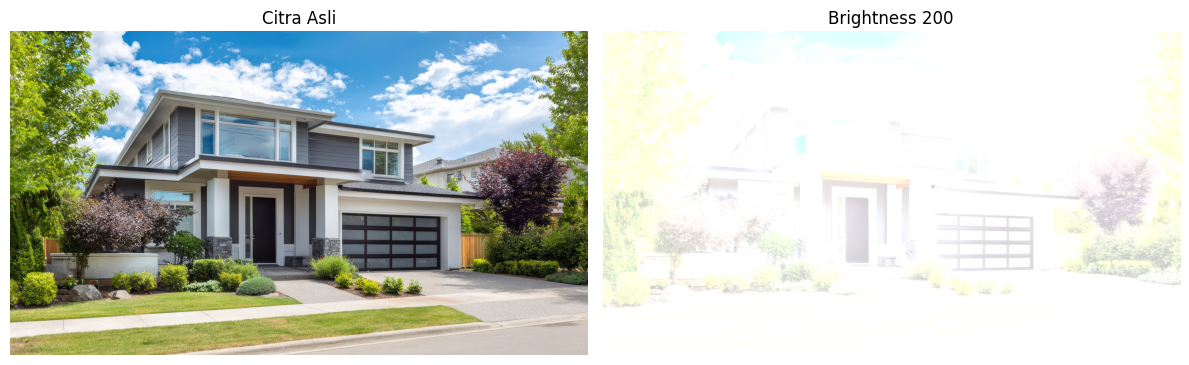

In [17]:
print('Transformasi Linear Brightness')
print('--------------------------------')

brightness = int(input('Masukkan nilai brightness, misalnya 50: '))

original = baca_gambar('house.jpg')

brightness_image = np.clip(
    original.astype(np.int16) + brightness,
    0,
    255
).astype(np.uint8)

tampilkan(
    [original, brightness_image],
    ['Citra Asli', f'Brightness {brightness}']
)

Tugas 1 — Inverse Citra

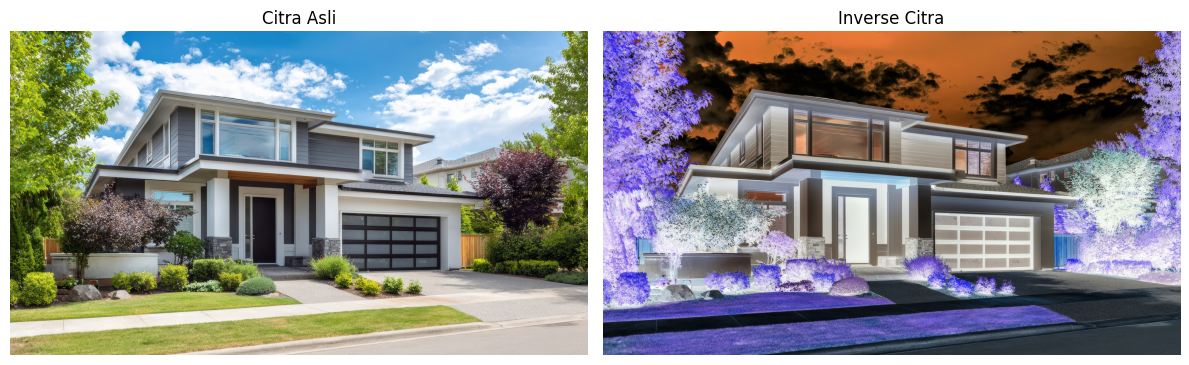

In [18]:
original = baca_gambar('house.jpg')

inverse_image = 255 - original

tampilkan(
    [original, inverse_image],
    ['Citra Asli', 'Inverse Citra']
)

Inverse citra membalik nilai setiap piksel. Piksel yang awalnya terang menjadi gelap, sedangkan piksel gelap menjadi terang. Warna pada citra juga berubah menjadi warna komplemennya. Contohnya, piksel bernilai 255 berubah menjadi 0.

Tugas 2 — Transformasi Contrast

Transformasi Contrast
----------------------
Masukkan nilai contrast antara -255 sampai 255, misalnya 50: -100


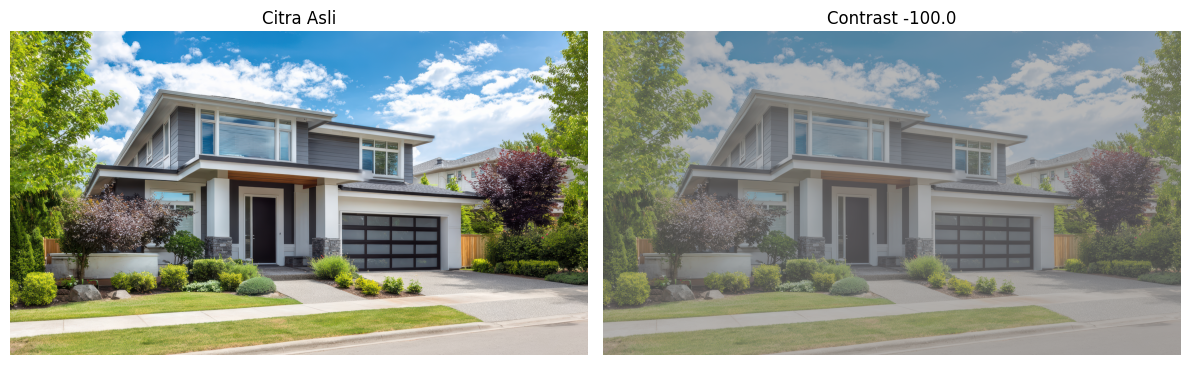

In [19]:
print('Transformasi Contrast')
print('----------------------')

contrast = float(input(
    'Masukkan nilai contrast antara -255 sampai 255, misalnya 50: '
))

if contrast < -255 or contrast > 255:
    raise ValueError('Nilai contrast harus berada antara -255 dan 255')

original = baca_gambar('house.jpg')

factor = (259 * (contrast + 255)) / (255 * (259 - contrast))

contrast_image = factor * (
    original.astype(np.float32) - 128
) + 128

contrast_image = np.clip(
    contrast_image,
    0,
    255
).astype(np.uint8)

tampilkan(
    [original, contrast_image],
    ['Citra Asli', f'Contrast {contrast}']
)

Nilai contrast positif membuat perbedaan antara bagian gelap dan terang semakin kuat. Sebaliknya, nilai contrast negatif membuat penyebaran warna lebih sempit sehingga citra terlihat lebih datar. Fungsi np.clip() digunakan agar hasil perhitungan tetap berada pada rentang 0–255.

Tugas 3 — Logarithmic Brightness

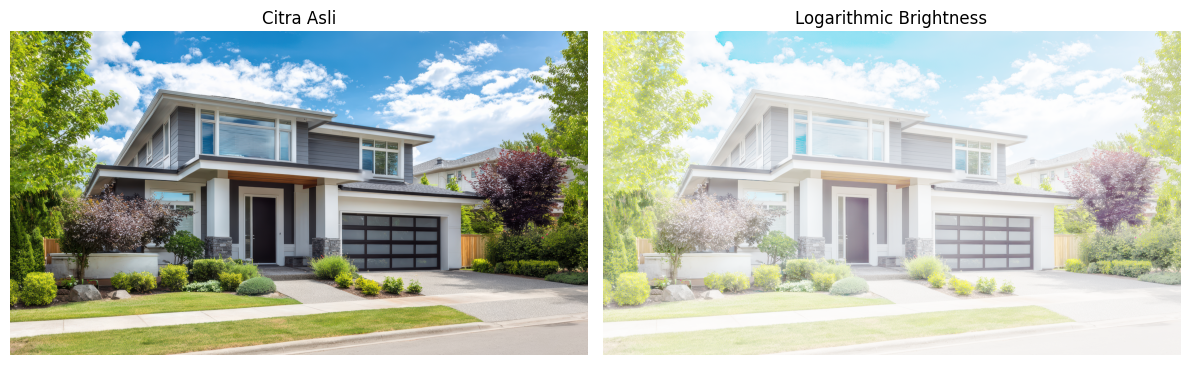

In [20]:
original = baca_gambar('house.jpg')

c = 255 / np.log(1 + 255)

log_image = c * np.log1p(
    original.astype(np.float32)
)

log_image = np.clip(
    log_image,
    0,
    255
).astype(np.uint8)

tampilkan(
    [original, log_image],
    ['Citra Asli', 'Logarithmic Brightness']
)

Transformasi logaritmik dapat menampilkan detail pada bagian citra yang gelap. Intensitas rendah diperluas, sedangkan intensitas tinggi dikompresi. Akibatnya, bagian gelap menjadi lebih mudah diamati tanpa meningkatkan seluruh piksel secara linear.

Tugas 4 — Grayscale

In [22]:
original = baca_gambar('paprika.jpg')

blue, green, red = cv.split(original)

blue = blue.astype(np.float32)
green = green.astype(np.float32)
red = red.astype(np.float32)

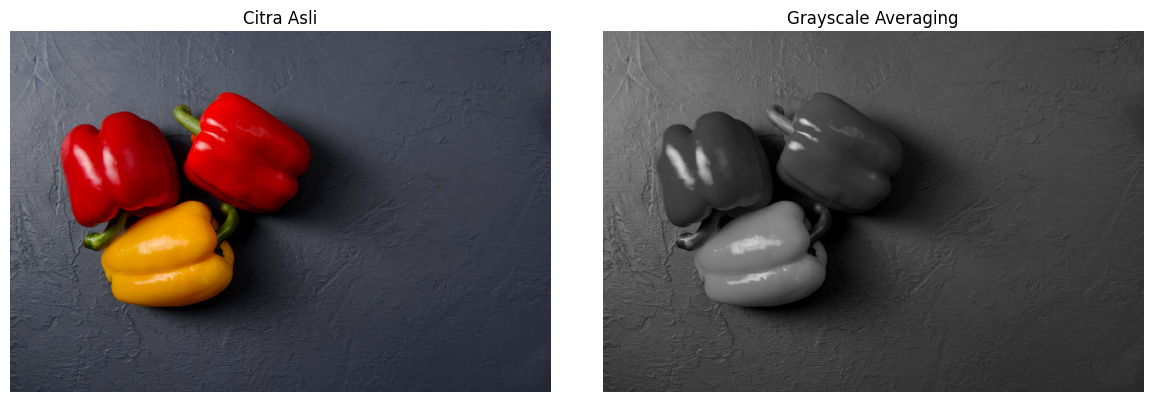

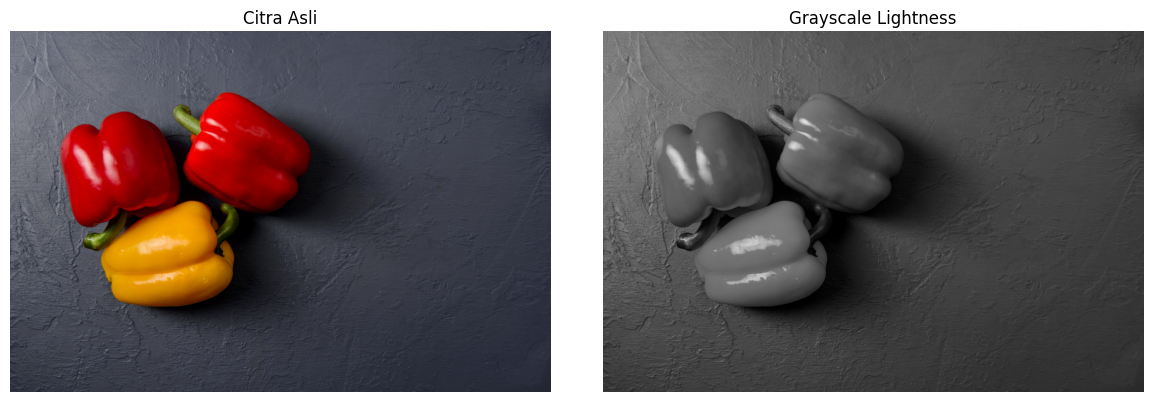

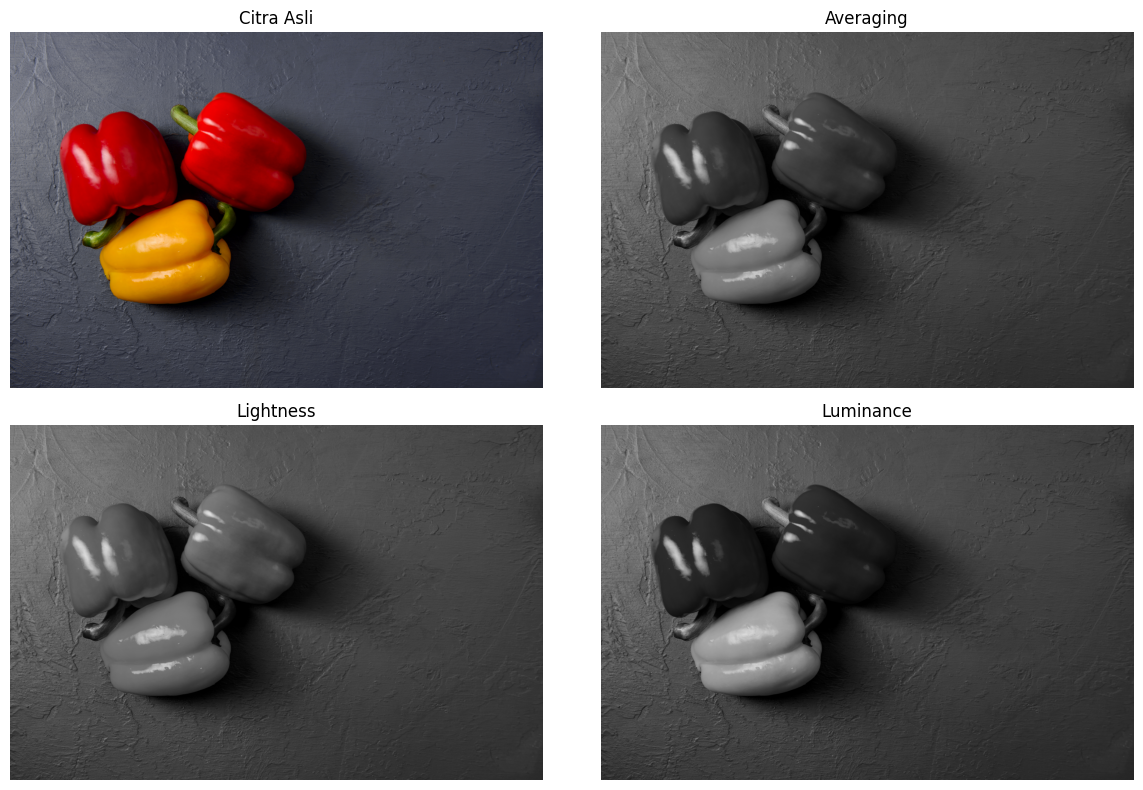

In [23]:
# Averaging
gray_average = (
    (red + green + blue) / 3
).astype(np.uint8)

tampilkan(
    [original, gray_average],
    ['Citra Asli', 'Grayscale Averaging']
)

# Lightness

nilai_max = np.maximum.reduce([red, green, blue])
nilai_min = np.minimum.reduce([red, green, blue])

gray_lightness = (
    (nilai_max + nilai_min) / 2
).astype(np.uint8)

tampilkan(
    [original, gray_lightness],
    ['Citra Asli', 'Grayscale Lightness']
)

# Luminance

gray_luminance = (
    0.21 * red +
    0.72 * green +
    0.07 * blue
)

gray_luminance = np.clip(
    gray_luminance,
    0,
    255
).astype(np.uint8)

tampilkan(
    [
        original,
        gray_average,
        gray_lightness,
        gray_luminance
    ],
    [
        'Citra Asli',
        'Averaging',
        'Lightness',
        'Luminance'
    ],
    columns=2
)

Ketiga metode menghasilkan citra grayscale, tetapi tingkat kecerahannya berbeda.

Averaging memberikan bobot yang sama kepada channel merah, hijau, dan biru.
Lightness menggunakan nilai channel terbesar dan terkecil.
Luminance memberikan bobot paling besar pada channel hijau karena mata manusia lebih sensitif terhadap warna hijau.
Metode luminance umumnya terlihat paling alami dibandingkan dua metode lainnya.

Tugas 5 — Menampilkan Warna Merah Saja

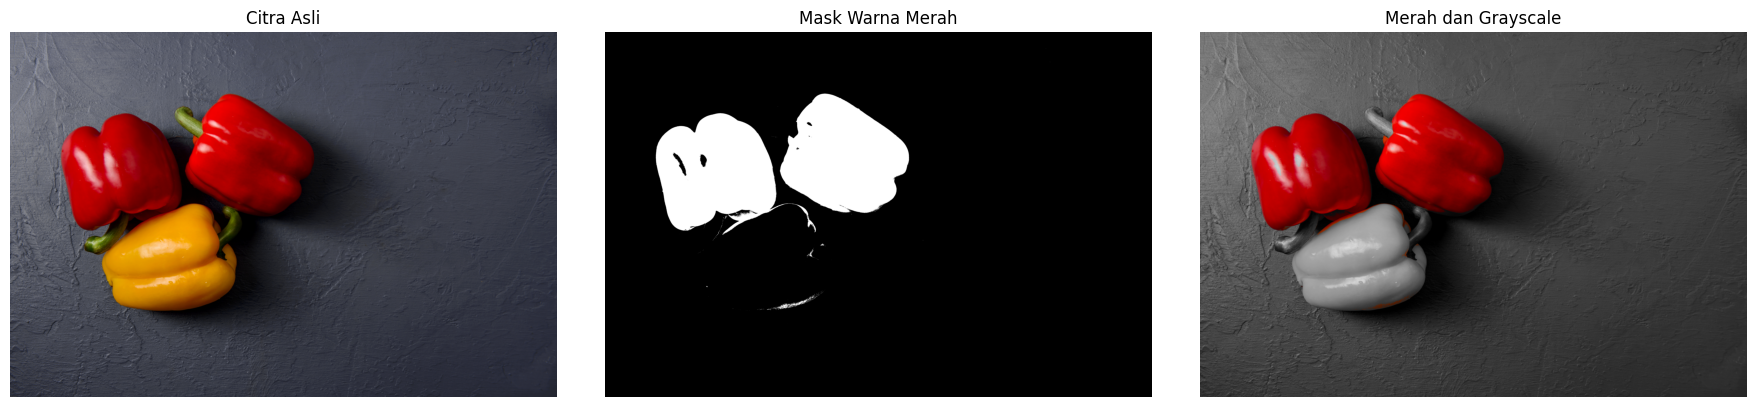

In [24]:
original = baca_gambar('paprika.jpg')

hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

# Merah berada pada dua bagian rentang hue HSV
lower_red_1 = np.array([0, 80, 50])
upper_red_1 = np.array([10, 255, 255])

lower_red_2 = np.array([170, 80, 50])
upper_red_2 = np.array([180, 255, 255])

mask_1 = cv.inRange(hsv, lower_red_1, upper_red_1)
mask_2 = cv.inRange(hsv, lower_red_2, upper_red_2)

red_mask = cv.bitwise_or(mask_1, mask_2)

gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

selective_color = np.where(
    red_mask[:, :, np.newaxis] > 0,
    original,
    gray_bgr
)

tampilkan(
    [original, red_mask, selective_color],
    ['Citra Asli', 'Mask Warna Merah', 'Merah dan Grayscale'],
    columns=3
)

Ruang warna HSV digunakan karena lebih mudah memisahkan warna berdasarkan hue. Warna merah memiliki dua rentang hue, yaitu di sekitar 0 dan 180. Piksel yang masuk rentang merah dipertahankan, sedangkan piksel lainnya diganti dengan hasil grayscale.

Tugas 6 — Gamma Correction

Gamma Correction pada Citra
----------------------------
Masukkan nilai gamma, misalnya 3: 0.5


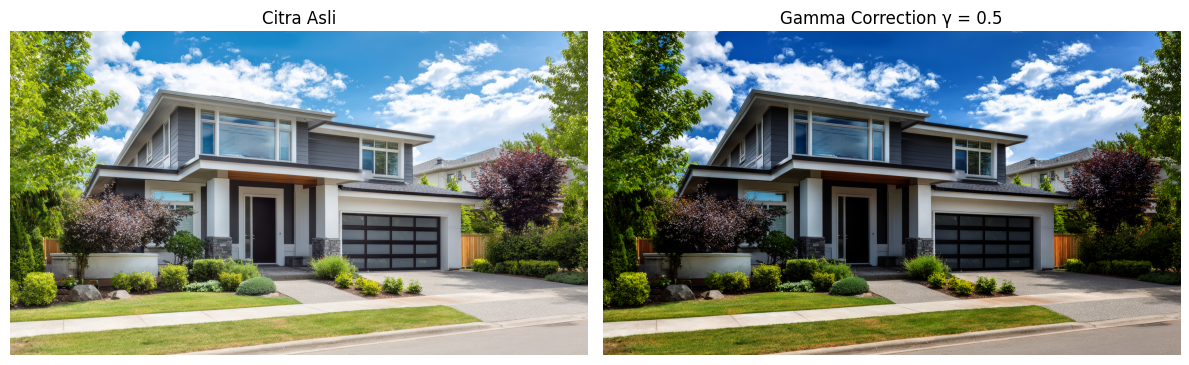

In [25]:
print('Gamma Correction pada Citra')
print('----------------------------')

try:
    gamma = float(input('Masukkan nilai gamma, misalnya 3: '))
except ValueError:
    raise ValueError('Nilai gamma harus berupa angka')

if gamma <= 0:
    raise ValueError('Nilai gamma harus lebih besar dari 0')

original = baca_gambar('house.jpg')

normalized = original.astype(np.float32) / 255.0

gamma_image = 255 * np.power(
    normalized,
    1 / gamma
)

gamma_image = np.clip(
    gamma_image,
    0,
    255
).astype(np.uint8)

tampilkan(
    [original, gamma_image],
    ['Citra Asli', f'Gamma Correction γ = {gamma}']
)

Pada rumus gamma correction yang digunakan modul:

a. gamma = 1 tidak mengubah citra;
b. gamma > 1 membuat citra lebih terang; </br>
c. 0 < gamma < 1 membuat citra lebih gelap.

Gamma correction bersifat nonlinier sehingga perubahan pada daerah gelap dan terang tidak sama besar.

Tugas 7 — Simulasi Image Depth

Masukkan bit depth antara 1 sampai 8, misalnya 2: 3
Bit depth       : 3
Jumlah tingkat  : 8
Nilai intensitas: [  0  36  72 109 145 182 218]


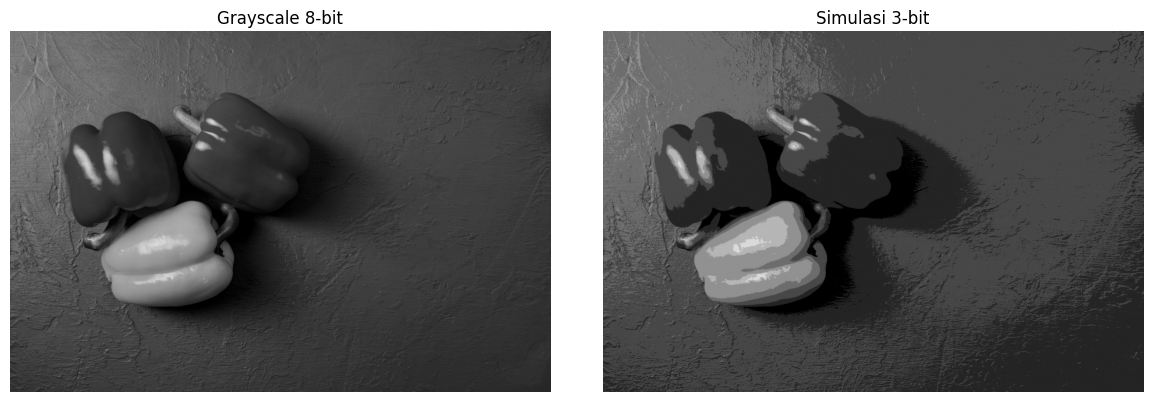

In [26]:
bit_depth = int(
    input('Masukkan bit depth antara 1 sampai 8, misalnya 2: ')
)

if bit_depth < 1 or bit_depth > 8:
    raise ValueError('Bit depth harus berada antara 1 dan 8')

original = baca_gambar(
    'paprika.jpg',
    cv.IMREAD_GRAYSCALE
)

jumlah_tingkat = 2 ** bit_depth
level = 255 / (jumlah_tingkat - 1)

depth_image = np.round(
    original.astype(np.float32) / level
) * level

depth_image = np.clip(
    depth_image,
    0,
    255
).astype(np.uint8)

print('Bit depth       :', bit_depth)
print('Jumlah tingkat  :', jumlah_tingkat)
print('Nilai intensitas:', np.unique(depth_image))

tampilkan(
    [original, depth_image],
    ['Grayscale 8-bit', f'Simulasi {bit_depth}-bit']
)

Semakin kecil bit depth, semakin sedikit variasi intensitas yang dapat ditampilkan. Pada 2-bit hanya terdapat empat tingkat intensitas. Akibatnya, perpindahan warna terlihat kasar dan detail citra berkurang. Percobaan ini hanya menyimulasikan jumlah tingkat warna; file hasilnya tetap disimpan sebagai citra 8-bit.

Tugas 8 — Average Denoising dan PSNR

In [27]:
# Cell fungsi PSNR
def hitung_psnr(image_1, image_2):
    image_1 = image_1.astype(np.float64)
    image_2 = image_2.astype(np.float64)

    mse = np.mean((image_1 - image_2) ** 2)

    if mse == 0:
        return float('inf')

    return 20 * np.log10(255.0 / np.sqrt(mse))

In [47]:
# Membaca citra asli dan seluruh citra noise

original = baca_gambar('galaxy.jpg')

noise_paths = sorted(
    glob.glob(os.path.join(BASE_PATH, 'noises', 'noise*.jpg'))
)

noise_images = []

for path in noise_paths:
    image = cv.imread(path)

    if image is not None and image.shape == original.shape:
        noise_images.append(image)

print('Jumlah citra noise yang berhasil dibaca:', len(noise_images))

Jumlah citra noise yang berhasil dibaca: 100


In [48]:
# Melakukan average denoising

def average_denoising(images, jumlah):
    if len(images) < jumlah:
        raise ValueError(
            f'Citra tersedia hanya {len(images)}, '
            f'tetapi diminta {jumlah}'
        )

    kumpulan = np.stack(
        images[:jumlah]
    ).astype(np.float32)

    hasil = np.mean(kumpulan, axis=0)

    return np.clip(
        hasil,
        0,
        255
    ).astype(np.uint8)

In [2]:
# Menguji 10, 20, 40, 80, dan 100 citra

jumlah_percobaan = [10, 20, 40, 80, 100]

hasil_denoising = {}
data_psnr = []

for jumlah in jumlah_percobaan:
    hasil = average_denoising(noise_images, jumlah)
    nilai_psnr = hitung_psnr(original, hasil)

    hasil_denoising[jumlah] = hasil

    data_psnr.append({
        'Jumlah Citra': jumlah,
        'Nilai PSNR (dB)': nilai_psnr
    })

tabel_psnr = pd.DataFrame(data_psnr)
tabel_psnr['Kenaikan PSNR (dB)'] = (
    tabel_psnr['Nilai PSNR (dB)'].diff()
)

display(tabel_psnr)

NameError: name 'average_denoising' is not defined

In [ ]:
# Menampilkan hasilnya

images = [original]
titles = ['Citra Asli']

for jumlah in jumlah_percobaan:
    images.append(hasil_denoising[jumlah])
    titles.append(
        f'Average {jumlah} Citra\n'
        f'PSNR = {data_psnr[jumlah_percobaan.index(jumlah)]["Nilai PSNR (dB)"]:.2f} dB'
    )

tampilkan(images, titles, columns=3)